In [1]:
import os

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"{cls}: {num_images} images")

acne: 2060 images
blackheades: 1970 images
dark spots: 2126 images
pores: 1632 images
wrinkles: 1982 images


In [2]:
from PIL import Image
import os

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)

sizes = set()
formats = set()
corrupt_files = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                sizes.add(img.size)
                formats.add(img.format)
        except Exception as e:
            corrupt_files.append(fpath)

print(f"Unique image sizes found: {len(sizes)}")
print(f"Sample sizes: {list(sizes)[:5]}")
print(f"Formats found: {formats}")
print(f"Corrupt files: {len(corrupt_files)}")
if corrupt_files:
    print(corrupt_files[:5])

Unique image sizes found: 621
Sample sizes: [(640, 320), (1600, 1064), (1200, 1600), (640, 338), (520, 520)]
Formats found: {'JPEG'}
Corrupt files: 0


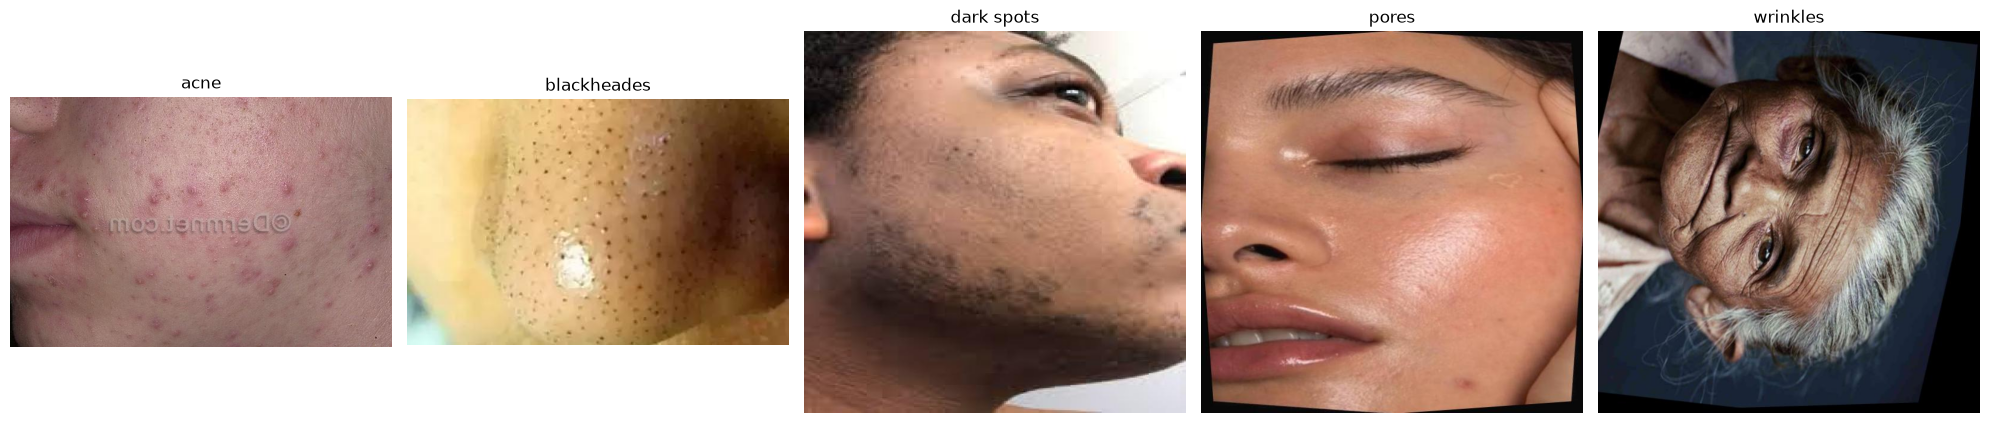

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import os

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)

fig, axes = plt.subplots(1, len(classes), figsize=(20, 5))
for ax, cls in zip(axes, classes):
    cls_path = os.path.join(data_dir, cls)
    sample_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, sample_file))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()


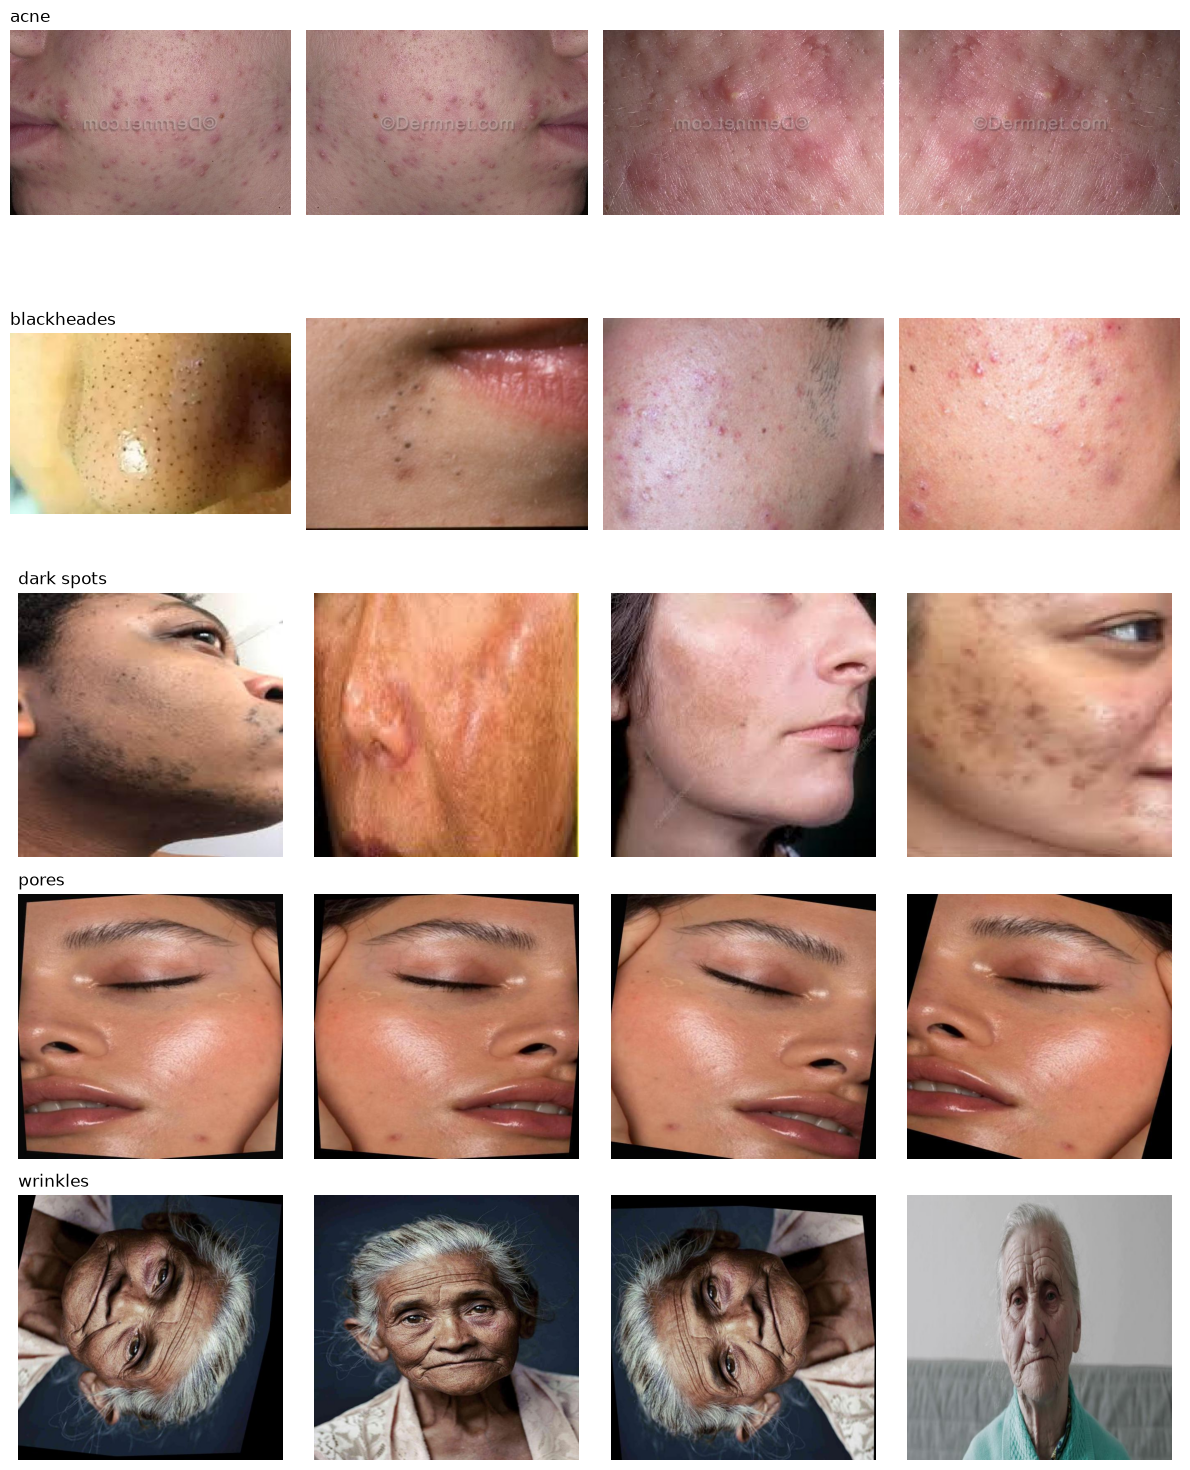

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)
n_samples = 4

fig, axes = plt.subplots(len(classes), n_samples, figsize=(12, 15))
for row, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    files = os.listdir(cls_path)[:n_samples]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(cls_path, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=12)
    axes[row, 0].set_title(cls, fontsize=12, loc='left')
plt.tight_layout()
plt.show()


In [5]:
import hashlib
from PIL import Image
import os

def image_hash(filepath, hash_size=8):
    with Image.open(filepath) as img:
        img = img.convert("L").resize((hash_size, hash_size))
        pixels = list(img.getdata())
        avg = sum(pixels) / len(pixels)
        return "".join("1" if p > avg else "0" for p in pixels)

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)

for cls in ["pores", "wrinkles"]:
    cls_path = os.path.join(data_dir, cls)
    hashes = {}
    duplicates = 0
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        h = image_hash(fpath)
        if h in hashes:
            duplicates += 1
        else:
            hashes[h] = fname
    print(f"{cls}: {duplicates} likely near-duplicates out of {len(os.listdir(cls_path))} images")

C:\Users\asus\AppData\Local\Temp\ipykernel_26432\2423861630.py:8: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


pores: 548 likely near-duplicates out of 1632 images
wrinkles: 373 likely near-duplicates out of 1982 images


In [6]:
import hashlib
from PIL import Image
import os

def image_hash(filepath, hash_size=8):
    with Image.open(filepath) as img:
        img = img.convert("L").resize((hash_size, hash_size))
        pixels = list(img.getdata())
        avg = sum(pixels) / len(pixels)
        return "".join("1" if p > avg else "0" for p in pixels)

data_dir = r"data\Skin v2"
classes = os.listdir(data_dir)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    hashes = {}
    duplicates = 0
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        h = image_hash(fpath)
        if h in hashes:
            duplicates += 1
        else:
            hashes[h] = fname
    print(f"{cls}: {duplicates} likely near-duplicates out of {len(os.listdir(cls_path))} images")

C:\Users\asus\AppData\Local\Temp\ipykernel_26432\3345306672.py:8: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


acne: 36 likely near-duplicates out of 2060 images
blackheades: 647 likely near-duplicates out of 1970 images
dark spots: 925 likely near-duplicates out of 2126 images
pores: 548 likely near-duplicates out of 1632 images
wrinkles: 373 likely near-duplicates out of 1982 images


In [1]:
import os
import shutil
from PIL import Image

def image_hash(filepath, hash_size=8):
    with Image.open(filepath) as img:
        img = img.convert("L").resize((hash_size, hash_size))
        pixels = list(img.getdata())
        avg = sum(pixels) / len(pixels)
        return "".join("1" if p > avg else "0" for p in pixels)

data_dir = r"data\Skin v2"
clean_dir = r"data\cleaned"
classes = os.listdir(data_dir)

os.makedirs(clean_dir, exist_ok=True)

for cls in classes:
    src_path = os.path.join(data_dir, cls)
    dst_path = os.path.join(clean_dir, cls)
    os.makedirs(dst_path, exist_ok=True)

    seen_hashes = set()
    kept = 0
    for fname in os.listdir(src_path):
        fpath = os.path.join(src_path, fname)
        h = image_hash(fpath)
        if h not in seen_hashes:
            seen_hashes.add(h)
            shutil.copy(fpath, os.path.join(dst_path, fname))
            kept += 1

    print(f"{cls}: kept {kept} unique images (from {len(os.listdir(src_path))})")

C:\Users\asus\AppData\Local\Temp\ipykernel_14148\307752428.py:8: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(img.getdata())


acne: kept 2024 unique images (from 2060)
blackheades: kept 1323 unique images (from 1970)
dark spots: kept 1201 unique images (from 2126)
pores: kept 1084 unique images (from 1632)
wrinkles: kept 1609 unique images (from 1982)
